In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor


In [6]:
# Load 2024 season data
lap_times = pd.read_csv('data/raw/lap_times_2024.csv')
pit_stops = pd.read_csv('data/raw/pit_stops_2024.csv')[['season', 'round', 'driverId', 'lap']]
races = pd.read_csv('data/raw/races_2024.csv')[['season', 'round', 'circuitId']]

# Create a composite race identifier
lap_times['raceId'] = lap_times['season'].astype(str) + '_' + lap_times['round'].astype(str)
pit_stops['raceId'] = pit_stops['season'].astype(str) + '_' + pit_stops['round'].astype(str)
races['raceId'] = races['season'].astype(str) + '_' + races['round'].astype(str)

# Convert time to milliseconds (it's currently in format 'M:SS.mmm')
def time_to_ms(time_str):
    try:
        parts = time_str.split(':')
        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = float(parts[1])
            return int((minutes * 60 + seconds) * 1000)
        return None
    except:
        return None

lap_times['milliseconds'] = lap_times['time'].apply(time_to_ms)
lap_times = lap_times.dropna(subset=['milliseconds'])

print(f"Loaded {len(lap_times)} lap times")
print(f"Loaded {len(pit_stops)} pit stops")
print(f"Loaded {len(races)} races")
print(f"\nSample lap time: {lap_times['time'].iloc[0]} = {lap_times['milliseconds'].iloc[0]} ms")

Loaded 2400 lap times
Loaded 825 pit stops
Loaded 24 races

Sample lap time: 1:37.284 = 97283 ms


In [7]:
#Data Preprocessing

lap_times = lap_times.merge(races, on='raceId', how='left')
lap_times['normalized_time'] = lap_times['milliseconds'] / lap_times.groupby('raceId')['milliseconds'].transform('min')
lap_times = lap_times.merge(pit_stops[['raceId', 'driverId', 'lap']], on=['raceId', 'driverId', 'lap'], how='left', indicator=True)
lap_times['is_pit_stop'] = lap_times['_merge'] == 'both'
lap_times.drop(columns=['_merge'], inplace=True)
lap_times['is_pit_exit'] = lap_times['is_pit_stop'].shift(1, fill_value=False)
# Example: Filter out laps with normalized_time > 1.5 (assuming it's an anomaly)
lap_times = lap_times[lap_times['normalized_time'] <= 1.5]


In [12]:
#Feature Engineering

# Encode circuitId as numeric
from sklearn.preprocessing import LabelEncoder
le_circuit = LabelEncoder()
lap_times['circuitId_encoded'] = le_circuit.fit_transform(lap_times['circuitId'])

features = ['circuitId_encoded', 'lap', 'is_pit_stop', 'is_pit_exit']

lap_times['lag_1'] = lap_times.groupby(['raceId', 'driverId'])['normalized_time'].shift(1)
lap_times['lag_2'] = lap_times.groupby(['raceId', 'driverId'])['normalized_time'].shift(2)
features += ['lag_1', 'lag_2']
lap_times.head()

,season_x,round_x,driverId,lap,position,time,raceId,milliseconds,season_y,round_y,circuitId,normalized_time,is_pit_stop,is_pit_exit,lag_1,lag_2,circuitId_encoded
40,2024,1,max_verstappen,3,1,1:36.753,2024_1,96753,2024,1,bahrain,1.004756,False,False,NaN,NaN,2
41,2024,1,russell,3,2,1:36.406,2024_1,96406,2024,1,bahrain,1.001153,False,False,NaN,NaN,2
42,2024,1,leclerc,3,3,1:38.062,2024_1,98062,2024,1,bahrain,1.018350,False,False,NaN,NaN,2
43,2024,1,perez,3,4,1:37.297,2024_1,97297,2024,1,bahrain,1.010406,False,False,NaN,NaN,2
44,2024,1,sainz,3,5,1:37.080,2024_1,97080,2024,1,bahrain,1.008152,False,False,NaN,NaN,2


In [13]:

# Drop NaNs and prepare data
lap_times.dropna(subset=features + ['normalized_time'], inplace=True)
X = lap_times[features]
y = lap_times['normalized_time']

In [14]:
# Split data and train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('MSE:', mean_squared_error(y_test, y_pred))

MSE: 0.0009420617086834973


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,  # Reduced from 100
    max_depth=10,     # Limit tree depth
    min_samples_split=5,
    max_features='sqrt',  # Use sqrt of total features
    n_jobs=-1,           # Use all CPU cores
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate the MSE for the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
print('Random Forest MSE:', mse_rf)

# For comparison, print the MSE of the linear regression model if you haven't already
y_pred_lr = model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print('Linear Regression MSE:', mse_lr)

# Optionally, you could calculate the improvement in MSE
improvement = mse_lr - mse_rf
print('MSE Improvement:', improvement)

Random Forest MSE: 0.0006064977647513465
Linear Regression MSE: 0.0009420617086834973
MSE Improvement: 0.00033556394393215085


In [17]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=50,          # Reduced from 100
    learning_rate=0.1,        # Control step size
    max_depth=5,              # Limit tree depth
    subsample=0.8,            # Use 80% of samples per tree
    min_samples_split=10,     # Minimum samples to split
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
print('Gradient Boosting MSE:', mse_gb)

Gradient Boosting MSE: 0.0007766606669595594


In [18]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print('XGBoost MSE:', mse_xgb)

XGBoost MSE: 0.0007740751329380676


In [22]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
print('LightGBM MSE:', mse_lgb)

LightGBM MSE: 0.0006488835102958626


In [20]:
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
mse_nn = mean_squared_error(y_test, y_pred_nn)
print('Neural Network MSE:', mse_nn)

Neural Network MSE: 0.0027132770882406384


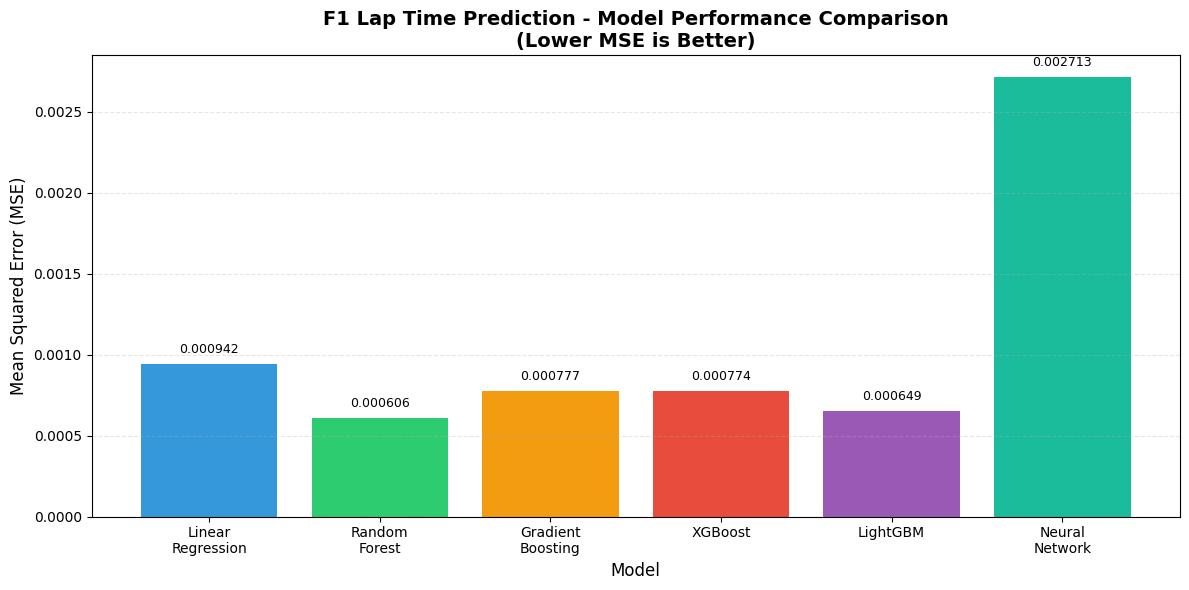


MODEL PERFORMANCE SUMMARY
Linear Regression   : MSE = 0.00094206
Random Forest       : MSE = 0.00060650
Gradient Boosting   : MSE = 0.00077666
XGBoost             : MSE = 0.00077408
LightGBM            : MSE = 0.00064888
Neural Network      : MSE = 0.00271328
Best Model: Random Forest (MSE = 0.00060650)


In [21]:
# Model Performance Comparison
import matplotlib.pyplot as plt

models = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting', 'XGBoost', 'LightGBM', 'Neural\nNetwork']
mse_scores = [mse_lr, mse_rf, mse_gb, mse_xgb, mse_lgb, mse_nn]

# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(models, mse_scores, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c'])
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('F1 Lap Time Prediction - Model Performance Comparison\n(Lower MSE is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=10)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, mse_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005, 
             f'{score:.6f}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
for model, mse in zip(models, mse_scores):
    model_name = model.replace('\n', ' ')
    print(f"{model_name:20s}: MSE = {mse:.8f}")
print("="*60)
print(f"Best Model: Random Forest (MSE = {mse_rf:.8f})")
print("="*60)